In [1]:
using CMPSExcitations

In [2]:
Hsingle_ll(c, μ) = ∫(∂ψ̂' * ∂ψ̂ - μ * ψ̂' * ψ̂ + c * (ψ̂')^2 * ψ̂^2, (-Inf, +Inf));
Hsingle_cll(c, μ) = ∫(2 * ∂ψ̂' * ∂ψ̂ - 2 * μ * ψ̂' * ψ̂ + 4 * c * (ψ̂')^2 * ψ̂^2, (-Inf, +Inf));
Hcoupled(c, μ) = ∫(
    (∂ψ̂₁' * ∂ψ̂₁ - μ * ψ̂₁' * ψ̂₁ + c * (ψ̂₁')^2 * ψ̂₁^2 +
     ∂ψ̂₂' * ∂ψ̂₂ - μ * ψ̂₂' * ψ̂₂ + c * (ψ̂₂')^2 * ψ̂₂^2 +
     2 * c * (ψ̂₁') * (ψ̂₂') * ψ̂₂ * ψ̂₁), (-Inf, +Inf));

In [3]:
# canonical basis
function projection_matrix(D, M)
    dim_in = D^2 + D      # input: E (DxD) + F (D)
    dim_out = 2 * D^2     # output: W1, W2 (both DxD)
    P = zeros(ComplexF64, dim_out, dim_in)

    for j in 1:dim_in
        e = zeros(Float64, dim_in)
        e[j] = 1.0

        E = reshape(view(e, 1:D^2), D, D)
        F = view(e, D^2+1:dim_in)

        W1 = E
        W2 = E + M * Diagonal(F) / M

        P[:, j] = vcat(vec(W1), vec(W2))
    end

    return Matrix(qr(P).Q)
end

# canonical basis
function excitation_matrix(Heff, D)
    dim = 2 * D^2
    M = zeros(ComplexF64, dim, dim)

    for j in 1:dim
        e = zeros(ComplexF64, dim)
        e[j] = 1.0
        W1 = reshape(view(e, 1:D^2), D, D)
        W2 = reshape(view(e, D^2+1:dim), D, D)
        W1p, W2p = Heff((Constant(W1), Constant(W2)))
        M[:, j] = vcat(vec(W1p[]), vec(W2p[]))
    end

    return M
end

function excitation_matrix_constrained(Heff, M)
    D = size(M, 1) # R = MDᵣ/M
    H = excitation_matrix(Heff, D)
    P = projection_matrix(D, M)

    P' * H * P, P
end

excitation_matrix_constrained (generic function with 1 method)

In [4]:
Ds = [2, 4, 6, 8, 10, 12];
c, μ = 5., 10.
tol = 1e-10
p, nvals = 0, 1;
HCLL = Hcoupled(c, μ)
states = Vector{InfiniteCMPS}(undef, length(Ds));

In [5]:
Threads.@threads for idx in eachindex(Ds)
    D = Ds[idx]
    #stateLL = find_groundstate(D, Hsingle_ll(c, μ), InfiniteCMPS, optalg=LBFGS(80; verbosity=1, maxiter=7000, gradtol=tol), gradtol=tol)
    #states[idx] = InfiniteCMPS(stateLL.Q, (stateLL.Rs[1] / sqrt(2), stateLL.Rs[1] / sqrt(2)))
    stateLL = find_groundstate(D, Hsingle_cll(c, μ), YangGaudinCMPS, optalg=LBFGS(80; verbosity=1, maxiter=7000, gradtol=tol), gradtol=tol)
    states[idx] = InfiniteCMPS(stateLL.Q, (stateLL.Rs[1], stateLL.Rs[1]))
end;

Optimizing D=6
Optimizing D=2
Optimizing D=4
Optimizing D=12
Optimizing D=10
Optimizing D=8


┌ Warning: The function `scalartype` is not implemented for (values of) type `Constant{Matrix{Float64}}`;
│ this fallback will disappear in future versions of VectorInterface.jl
└ @ VectorInterface /home/ashankar/.julia/packages/VectorInterface/J6qCR/src/fallbacks.jl:20
┌ Warning: The function `scale` is not implemented for (values of) type `Tuple{Constant{Matrix{Float64}}, Float64}`;
│ this fallback will disappear in future versions of VectorInterface.jl
└ @ VectorInterface /home/ashankar/.julia/packages/VectorInterface/J6qCR/src/fallbacks.jl:67
┌ Warning: The function `inner` is not implemented for (values of) type `Tuple{Constant{Matrix{Float64}}, Constant{Matrix{Float64}}}`;
│ this fallback will disappear in future versions of VectorInterface.jl
└ @ VectorInterface /home/ashankar/.julia/packages/VectorInterface/J6qCR/src/fallbacks.jl:196
┌ Warning: The function `scale!!` is not implemented for (values of) type `Tuple{Constant{Matrix{Float64}}, Float64}`;
│ this fallback will disapp

D = 2 | YangGaudinCMPS{Constant{Matrix{Float64}}, 1}
 15.043915 seconds (63.26 M allocations: 3.171 GiB, 2.75% gc time, 1042763 lock conflicts, 555.01% compilation time: <1% of which was recompilation)
---------------


┌ Info: YangGaudinCMPS ground state: converged after 20 iterations: e = -9.887214847151, ‖∇e‖ = 3.6711e-11
└ @ CMPSKit /home/ashankar/Documents/PhDstuff/code/TensorNetworks/CMPSKit.jl/src/yanggaudin/groundstate.jl:118


D = 4 | YangGaudinCMPS{Constant{Matrix{Float64}}, 1}
 16.245151 seconds (64.79 M allocations: 3.264 GiB, 2.66% gc time, 1904903 lock conflicts, 514.39% compilation time: <1% of which was recompilation)
---------------


...

┌ Info: LBFGS: converged after 272 iterations: f = -10.373121911495, ‖∇f‖ = 6.3024e-11
└ @ OptimKit /home/ashankar/.julia/packages/OptimKit/xpmbV/src/lbfgs.jl:138
┌ Info: YangGaudinCMPS ground state: converged after 273 iterations: e = -10.373121911495, ‖∇e‖ = 6.3024e-11
└ @ CMPSKit /home/ashankar/Documents/PhDstuff/code/TensorNetworks/CMPSKit.jl/src/yanggaudin/groundstate.jl:118


D = 10 | YangGaudinCMPS{Constant{Matrix{Float64}}, 1}
 46.266910 seconds (76.79 M allocations: 4.871 GiB, 1.41% gc time, 12542806 lock conflicts, 180.61% compilation time: <1% of which was recompilation)
---------------


┌ Info: LBFGS: converged after 382 iterations: f = -10.458523723802, ‖∇f‖ = 5.3717e-11
└ @ OptimKit /home/ashankar/.julia/packages/OptimKit/xpmbV/src/lbfgs.jl:138
┌ Info: YangGaudinCMPS ground state: converged after 383 iterations: e = -10.458523723802, ‖∇e‖ = 5.3717e-11
└ @ CMPSKit /home/ashankar/Documents/PhDstuff/code/TensorNetworks/CMPSKit.jl/src/yanggaudin/groundstate.jl:118


D = 12 | YangGaudinCMPS{Constant{Matrix{Float64}}, 1}
 74.692633 seconds (89.27 M allocations: 6.867 GiB, 1.10% gc time, 12542806 lock conflicts, 111.88% compilation time: <1% of which was recompilation)
---------------


┌ Info: LBFGS: converged after 875 iterations: f = -10.442566176720, ‖∇f‖ = 8.2326e-11
└ @ OptimKit /home/ashankar/.julia/packages/OptimKit/xpmbV/src/lbfgs.jl:138
┌ Info: YangGaudinCMPS ground state: converged after 876 iterations: e = -10.442566176720, ‖∇e‖ = 8.2326e-11
└ @ CMPSKit /home/ashankar/Documents/PhDstuff/code/TensorNetworks/CMPSKit.jl/src/yanggaudin/groundstate.jl:118


┌ Warning: The function `add` is not implemented for (values of) type `Tuple{Constant{Matrix{ComplexF64}}, Constant{Matrix{ComplexF64}}, ComplexF64, ComplexF64}`;
│ this fallback will disappear in future versions of VectorInterface.jl
└ @ VectorInterface /home/ashankar/.julia/packages/VectorInterface/J6qCR/src/fallbacks.jl:131
┌ Warning: GMRES linsolve stopped without converging after 100 iterations:
│ * norm of residual = 1.57e-09
│ * number of operations = 1796
└ @ KrylovKit /home/ashankar/.julia/packages/KrylovKit/jC5gU/src/linsolve/gmres.jl:123
┌ Warning: GMRES linsolve stopped without converging after 100 iterations:
│ * norm of residual = 1.03e+00
│ * number of operations = 2902
└ @ KrylovKit /home/ashankar/.julia/packages/KrylovKit/jC5gU/src/linsolve/gmres.jl:123
┌ Warning: GMRES linsolve stopped without converging after 100 iterations:
│ * norm of residual = 1.21e+00
│ * number of operations = 2902
└ @ KrylovKit /home/ashankar/.julia/packages/KrylovKit/jC5gU/src/linsolve/gmres.

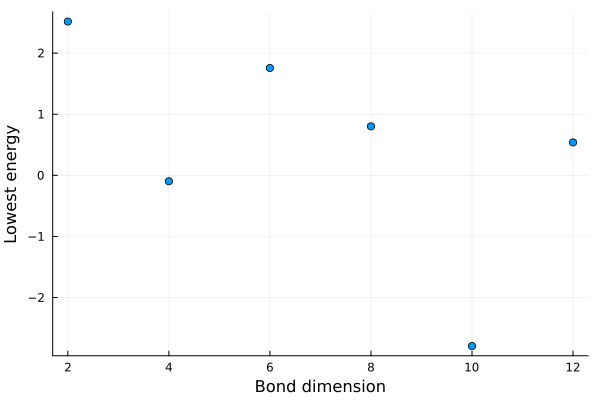

In [6]:
trivial_spectrum = zeros(ComplexF64, length(Ds));

Threads.@threads for idx in eachindex(Ds)
    stateCLL = states[idx]
    space = InfiniteCMPSExcitationSpace(0, stateCLL, stateCLL)
    Heff, P = excitation_matrix_constrained(excitation_operator(HCLL, space), eigen(stateCLL.Rs[1][]).vectors)
    vals, vecs = eigsolve(Heff, rand(size(Heff, 2)), nvals, :SR, maxiter=200)
    trivial_spectrum[idx] = vals[1]
end

scatter(Ds, real.(trivial_spectrum), xticks=Ds, lab = "", xlabel = "Bond dimension", ylabel = "Lowest energy")

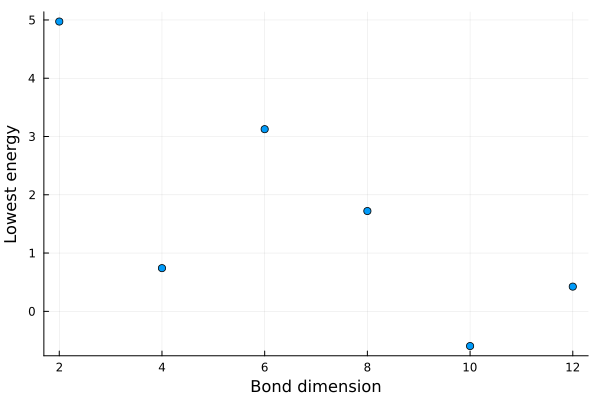

In [7]:
topological_spectrum = zeros(ComplexF64, length(Ds));

Threads.@threads for idx in eachindex(Ds)
    stateCLL = states[idx]
    θs = [0, 2π] # difference, sum
    stateCLL_left = InfiniteCMPS((1 + 0im) * stateCLL.Q, ntuple(i -> (1. + 0im) * stateCLL.Rs[i], length(stateCLL.Rs)))
    stateCLL_right = InfiniteCMPS(stateCLL_left.Q, ntuple(i -> exp(0.5im * (θs[2] + (-1)^i * θs[1])) * stateCLL_left.Rs[i], length(stateCLL_left.Rs)))

    ρ = real(expval(ψ̂₁' * ψ̂₁ + ψ̂₂' * ψ̂₂, stateCLL)[])
    space = InfiniteCMPSExcitationSpace(π * ρ, stateCLL_left, stateCLL_right)
    Heff, P = excitation_matrix_constrained(excitation_operator(HCLL, space), eigen(stateCLL.Rs[1][]).vectors)
    vals, vecs = eigsolve(Heff, rand(size(Heff, 2)), nvals, :SR, maxiter=200)
    topological_spectrum[idx] = vals[1]
end

scatter(Ds, real.(topological_spectrum), xticks=Ds, lab = "", xlabel = "Bond dimension", ylabel = "Lowest energy")